<a href="https://colab.research.google.com/github/CBravoR/AdvancedAnalyticsLabs/blob/master/notebooks/python/Lab_Stress_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stress Testing

In this lab we run the bank's own stress tests on a credit portfolio: the Pillar 1 test that the IRB rules ask for, and the IFRS 9 test that the accounting rules ask for. The two use the same scenarios and models. We will perform sensitivity tests first, then a macroeconomic scenario simulation, then migration, then the IFRS 9 side with the probability-weighted ECL, the staging thresholds and the cliff effect, and finally a reverse stress test.

As this is an example, we will simulate the bank's portfolio. The portfolio, the macro history and the default history all come from the one-factor model of Lecture 8, with the sign convention we have used during the course: **a positive Z is a good economy**, and an obligor defaults when its asset return falls below the default threshold,

$$\text{PD}(Z) = \Phi\left(\frac{\Phi^{-1}(\text{PD}_{TTC}) - \sqrt{\rho}\, Z}{\sqrt{1-\rho}}\right).$$

A 1-in-25 year event is therefore $Z = \Phi^{-1}(0.04) = -1.75$, and the Basel capital formula gives $Z = \Phi^{-1}(0.001) = -3.09$. Keep this in mind when you read formulas from other sources, where the sign may be flipped.

The lab has seven parts:

1. The simulated bank: portfolio, macro history, default history and capital.
2. Sensitivity tests at Level 0, 1 and 2, and the Basel-formula stress (lecture slides 13 to 15).
3. Macroeconomic scenarios through the systematic factor (slides 26 to 28).
4. Migration matrices under stress with the Z-shift (slide 29).
5. IFRS 9: lifetime PD under a scenario path and the probability-weighted ECL (slides 32 to 35).
6. SICR thresholds, the threshold matrix and the cliff effect (slides 36 to 39).
7. Reverse stress testing (slide 18).

Each part ends in a number a risk committee could act on: a capital ratio, a provision, or a scenario severity.

In [5]:
# Package imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import statsmodels.api as sm
%matplotlib inline

# Display floats with 4 decimal places and thousands separator
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
rng = np.random.default_rng(20260915)

In [6]:

# The one-factor model, Lecture 8 convention: positive Z is a good economy.
def pd_pit(pd_ttc, rho, z):
    return norm.cdf((norm.ppf(pd_ttc) - np.sqrt(rho) * z) / np.sqrt(1 - rho))

def rho_retail(pd_ttc):
    # Basel asset correlation for "other retail": 0.16 for small PDs, 0.03 for large ones.
    w = (1 - np.exp(-35 * pd_ttc)) / (1 - np.exp(-35))
    return 0.03 * w + 0.16 * (1 - w)

def k_irb(pd_ttc, lgd, rho):
    # Basel capital requirement per unit of EAD (retail: no maturity adjustment).
    # The 0.999 quantile is the conditional PD at Z = -3.09 in our convention.
    return lgd * pd_pit(pd_ttc, rho, norm.ppf(0.001)) - pd_ttc * lgd

## Part 1: Simulated bank portfolio

The portfolio has 20,000 loans on the bank's internal master scale. There are five performing
grades, AAA-AA, A, BB, B and C, and a sixth state, D, that holds the loans already in default.
The through-the-cycle PDs run from 5 basis points in the best grade to 14% in the worst, the
range the external ladder gives for the same letters, and most of the exposure sits in BB and B,
where a real bank book would normally be. Each loan also has an idiosyncratic component of its PD, so that two
loans in the same grade are not identical, a loss given default that rises with the grade, an
exposure, and a remaining maturity between one and seven years. Every loan remembers the grade it
had at origination, as IFRS 9 compares today's risk with the risk at that date. Some loans
have migrated since, in both directions.

Two points about the scale. First, I made it coarse on purpose: while five buckets are below Basel's seven bucket recommendation, I did not want to create too many categories for the course example. The scale is designed to be practical for the purposes of this lab, so each letter covers a range of the external ladder, and the A grade here spans what an
agency would call A and BBB. Second, D is a state. Nothing is originated into it,
a loan enters it and does not leave it inside this lab (as the regulation demands, deteriorated loans must remain in their own portfolio even if cured). It also appears only as the last column of
the migration matrix in Part 4.

To make the sensitivity tests of Part 2 concrete, each loan also has a behavioural **score** on a
300 to 900 scale, built from its PD with a fixed scorecard rule (600 points at odds of 50 to 1, 50
points to double the odds), and a monthly **income** that feeds the score. Lecture slide 13
stresses the data (Level 0), the score (Level 1) and the ratings or PDs (Level 2). We need all
three layers to do that.

In [7]:
N = 20_000
# The internal master scale: five performing grades, plus D for default (Part 4).
grades = ['AAA-AA', 'A', 'BB', 'B', 'C']
pd_grade = pd.Series([0.0005, 0.0020, 0.0090, 0.0350, 0.1400], index=grades)
lgd_grade = pd.Series([0.30, 0.34, 0.40, 0.45, 0.52], index=grades)

# Grade today and grade at origination: most loans stayed, some migrated.
# The mass of the book is in BB and B, and the investment-grade part is thin.
g_now = rng.choice(5, size=N, p=[0.07, 0.25, 0.43, 0.20, 0.05])
shift = rng.choice([-1, 0, 1], size=N, p=[0.15, 0.70, 0.15])
g_orig = np.clip(g_now - shift, 0, 4)

as_grade = lambda idx: pd.Categorical(np.array(grades)[idx], categories=grades, ordered=True)
port = pd.DataFrame({
    'grade': as_grade(g_now),
    'grade_orig': as_grade(g_orig),
    'pd_grade': pd_grade.values[g_now],
    'lgd': lgd_grade.values[g_now],
    'ead': np.round(rng.lognormal(mean=np.log(25_000), sigma=0.6, size=N), 0),
    'maturity': rng.integers(1, 8, size=N),          # remaining years
})
# Idiosyncratic component: same grade, different PD. u is the standardized "quality within grade".
port['u'] = rng.normal(0, 1, N)
port['pd_ttc'] = norm.cdf(norm.ppf(port['pd_grade']) + 0.25 * port['u'])
port['pd_orig'] = norm.cdf(norm.ppf(pd_grade.values[g_orig]) + 0.25 * port['u'])
port['rho'] = rho_retail(port['pd_ttc'])

# A fixed scorecard rule: 600 points at odds of 50 to 1, and 50 points per doubling of the odds.
# Income explains part of the score, which is what the Level 0 stress moves.
port['income'] = np.round(rng.lognormal(mean=np.log(2_500), sigma=0.4, size=N), 0)
ODDS_REF, PDO = 50.0, 50.0
def score_from_pd(p):
    return 600 + PDO * np.log2((1 - p) / p / ODDS_REF)
def pd_from_score(s):
    return 1 / (1 + ODDS_REF * 2 ** ((s - 600) / PDO))
port['score'] = score_from_pd(port['pd_ttc'])
INCOME_BETA = 30   # score points per unit of log income, used for the Level 0 stress

print(f"{N:,} loans, total exposure {port['ead'].sum()/1e6:,.1f} million")
display(port.groupby('grade', observed=True).agg(loans=('ead', 'size'), exposure=('ead', 'sum'),
                                                 pd_ttc=('pd_ttc', 'mean'), lgd=('lgd', 'mean'),
                                                 score=('score', 'mean'),
                                                 maturity=('maturity', 'mean')).round(4))

20,000 loans, total exposure 598.0 million


,loans,exposure,pd_ttc,lgd,score,maturity
grade,,,,,,
AAA-AA,1473,"44,054,240.0000",0.0007,0.3000,867.9290,3.9593
A,4934,"146,181,781.0000",0.0026,0.3400,768.0853,4.0436
BB,8588,"254,715,058.0000",0.0110,0.4000,658.1874,4.0027
B,4008,"122,492,413.0000",0.0395,0.4500,558.5021,4.0404
C,997,"30,548,484.0000",0.1469,0.5200,450.0291,4.0702


### Capital

The Pillar 1 stress test asks **what happens to capital adequacy under a stressed situation?**, so we need a starting point: the IRB capital requirement of the portfolio, its risk-weighted assets, and the capital the bank holds. The capital requirement per unit of exposure follows the Basel formula of Lecture 8, with the retail asset correlation. Note that the formula is the one-factor PD at $Z = -3.09$ times the LGD, minus the expected loss, so the whole of Pillar 1 is already a stress test at one fixed, very severe, value of Z.

I give the bank a capital ratio of 12% of risk-weighted assets against a requirement of 10.5% (8% minimum plus a 2.5% conservation buffer). The gap of 1.5 percentage points is the buffer the stress tests have to respect. Both numbers are round and generic for the purposes of this lab only, real numbers will vary by institution.

In [8]:
port['K'] = k_irb(port['pd_ttc'], port['lgd'], port['rho'])
port['rwa'] = 12.5 * port['K'] * port['ead']
port['el'] = port['pd_ttc'] * port['lgd'] * port['ead']

RWA0 = port['rwa'].sum()
CAPITAL0 = 0.12 * RWA0
REQUIREMENT = 0.105     # 8% minimum plus the 2.5% conservation buffer
MINIMUM = 0.08

def capital_ratio(capital, rwa):
    return capital / rwa

print(f"Expected loss          {port['el'].sum()/1e6:8.2f} million  ({port['el'].sum()/port['ead'].sum():.2%} of exposure)")
print(f"Capital requirement K  {(port['K']*port['ead']).sum()/1e6:8.2f} million")
print(f"Risk-weighted assets   {RWA0/1e6:8.2f} million  (average risk weight {RWA0/port['ead'].sum():.0%})")
print(f"Capital held           {CAPITAL0/1e6:8.2f} million  (ratio {capital_ratio(CAPITAL0, RWA0):.1%}, requirement {REQUIREMENT:.1%})")

Expected loss              5.78 million  (0.97% of exposure)
Capital requirement K     18.35 million
Risk-weighted assets     229.40 million  (average risk weight 38%)
Capital held              27.53 million  (ratio 12.0%, requirement 10.5%)


### The macroeconomy and the default history

For the economy, we simulate fifteen years of quarterly data: GDP growth and the unemployment rate, with one recession in the middle. The systematic factor $Z_t$ follows the macroeconomy, positive when growth is above trend and unemployment below, plus noise that the macroeconomy does not explain. From $Z_t$ and the grade PDs we draw the number of defaults per grade and quarter, which gives us the default-rate history a bank would actually have. We keep the true $Z_t$ only to check our estimates later, as the bank would never observe it.

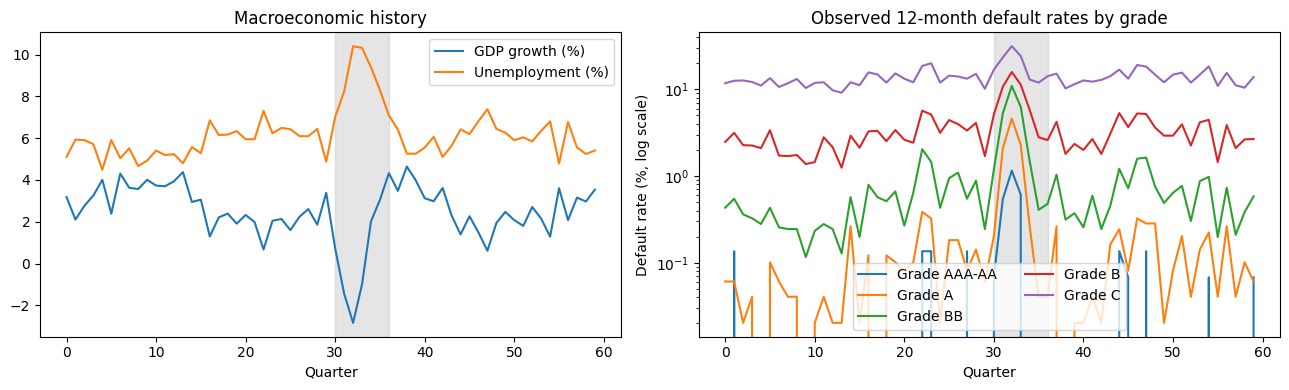

In [9]:
T = 60
t = np.arange(T)
gdp = 2.8 + 1.0 * np.sin(2 * np.pi * t / 28) + rng.normal(0, 0.7, T)
gdp[30:36] -= np.array([2.0, 4.5, 5.5, 4.0, 2.0, 1.0])            # the recession
unemp = 6.0 - 0.6 * (gdp - gdp.mean()) + rng.normal(0, 0.3, T)
unemp[31:40] += np.array([0.5, 1.5, 2.5, 3.0, 2.8, 2.2, 1.5, 0.8, 0.3])

z_true = 0.45 * (gdp - gdp.mean()) / gdp.std() - 0.35 * (unemp - unemp.mean()) / unemp.std() + rng.normal(0, 0.30, T)

# Default history: annualized default rate per grade and quarter, on a stable book of loans per grade.
n_grade = port.groupby('grade', observed=True).size().reindex(grades)
dr_hist = pd.DataFrame(index=t, columns=grades, dtype=float)
for g in grades:
    p_t = pd_pit(pd_grade[g], rho_retail(pd_grade[g]), z_true)
    dr_hist[g] = rng.binomial(int(n_grade[g]), p_t) / n_grade[g]
macro = pd.DataFrame({'gdp_growth': gdp, 'unemployment': unemp, 'z_true': z_true}, index=t)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(t, gdp, label='GDP growth (%)'); ax[0].plot(t, unemp, label='Unemployment (%)')
ax[0].axvspan(30, 36, color='grey', alpha=.2); ax[0].legend(); ax[0].set_xlabel('Quarter'); ax[0].set_title('Macroeconomic history')
for g in grades:
    ax[1].plot(t, 100 * dr_hist[g], label=f'Grade {g}')
ax[1].axvspan(30, 36, color='grey', alpha=.2); ax[1].set_yscale('log'); ax[1].legend(ncol=2); ax[1].set_xlabel('Quarter'); ax[1].set_ylabel('Default rate (%, log scale)')
ax[1].set_title('Observed 12-month default rates by grade')
plt.tight_layout(); plt.show()

## Part 2: Sensitivity tests

Lecture slide 13 defines three levels of sensitivity stress, matching the three levels of the validation lecture. Level 0 stresses the data, for example a 10% fall in income. Level 1 stresses the score, for example a 10% drop. Level 2 stresses the ratings or the PDs themselves: a one-notch downgrade, a doubling of PDs, a 50% increase in LGDs. Slide 15 lists the shocks that supervisors have used. Each test is a single, immediate change to one input, and we measure its effect on expected loss, capital requirements and the capital ratio.

The tests are easy to run and explain. What they cannot do is tell you how likely the shock is, or how the shocks move together, which we will do on Part 3.

In [10]:
def portfolio_numbers(df, pd_col='pd_ttc', lgd_col='lgd'):
    rho = rho_retail(df[pd_col])
    K = k_irb(df[pd_col], df[lgd_col], rho)
    rwa = (12.5 * K * df['ead']).sum()
    el = (df[pd_col] * df[lgd_col] * df['ead']).sum()
    # Extra expected loss relative to the base is provisioned, and provisions come out of capital.
    capital = CAPITAL0 - (el - port['el'].sum())
    return pd.Series({'EL (m)': el / 1e6, 'RWA (m)': rwa / 1e6, 'Capital ratio': capital / rwa})

def notch(df, n, share=1.0):
    # Downgrade a share of the loans by n notches, PD and LGD move to the new grade, idiosyncratic part kept.
    out = df.copy()
    hit = rng.random(len(out)) < share
    g = np.array([grades.index(x) for x in out['grade']])
    g_new = np.clip(g + n, 0, 4)
    g_new = np.where(hit, g_new, g)
    out['pd_ttc'] = norm.cdf(norm.ppf(pd_grade.values[g_new]) + 0.25 * out['u'])
    out['lgd'] = lgd_grade.values[g_new]
    return out

tests = {}
tests['Base'] = portfolio_numbers(port)

# Level 0: income falls 10% for everyone; the scorecard turns that into a score change, the score into a PD.
lvl0 = port.copy()
lvl0['score'] = port['score'] + INCOME_BETA * np.log(0.9)
lvl0['pd_ttc'] = pd_from_score(lvl0['score'])
tests['Level 0: income -10%'] = portfolio_numbers(lvl0)

# Level 1: the score itself drops 10%.
lvl1 = port.copy()
lvl1['score'] = 0.9 * port['score']
lvl1['pd_ttc'] = pd_from_score(lvl1['score'])
tests['Level 1: score -10%'] = portfolio_numbers(lvl1)

# Level 2: ratings and parameters.
tests['Level 2: one notch down, all'] = portfolio_numbers(notch(port, 1))
tests['Level 2: two notches down, 50%'] = portfolio_numbers(notch(port, 2, 0.5))
lvl2 = port.copy(); lvl2['pd_ttc'] = np.minimum(2 * port['pd_ttc'], 0.99)
tests['Level 2: PD +100%'] = portfolio_numbers(lvl2)
lvl2 = port.copy(); lvl2['lgd'] = np.minimum(1.5 * port['lgd'], 1.0)
tests['Level 2: LGD +50%'] = portfolio_numbers(lvl2)
lvl2 = port.copy(); lvl2['pd_ttc'] = np.minimum(2 * port['pd_ttc'], 0.99); lvl2['lgd'] = np.minimum(1.5 * port['lgd'], 1.0)
tests['Level 2: PD +100% and LGD +50%'] = portfolio_numbers(lvl2)

sens = pd.DataFrame(tests).T
sens['Ratio change (pp)'] = 100 * (sens['Capital ratio'] - sens.loc['Base', 'Capital ratio'])
sens.style.format({'EL (m)': '{:.2f}', 'RWA (m)': '{:.1f}', 'Capital ratio': '{:.2%}', 'Ratio change (pp)': '{:+.2f}'})

,EL (m),RWA (m),Capital ratio,Ratio change (pp)
Base,5.78,229.4,12.00%,+0.00
Level 0: income -10%,6.02,232.8,11.73%,-0.27
Level 1: score -10%,11.16,299.0,7.41%,-4.59
"Level 2: one notch down, all",16.97,377.0,4.33%,-7.67
"Level 2: two notches down, 50%",20.03,375.6,3.54%,-8.46
Level 2: PD +100%,11.56,285.5,7.62%,-4.38
Level 2: LGD +50%,8.67,344.1,7.16%,-4.84
Level 2: PD +100% and LGD +50%,17.34,428.3,3.73%,-8.27


The capital ratio in the table moves through both the numerator and the denominator: the extra expected loss is provisioned and stops being counted for capital, and the higher PDs or LGDs raise the risk weights. The 10% score drop translates to  a much larger impact than the baseline number implies. It removes 45 points from a loan in grade C and 87 points from a loan in grade AAA-AA. As 50 points is a doubling of the odds of default on this scorecard, a Level 1 test needs the scorecard's scale to be interpreted. The one-notch downgrade is significant given the master scale: with five grades a notch is a jump of a factor of four in PD, so a bank with a finer scale would report a much milder number for the same test, which shows the reason why Basel suggest 7-15 grades. 

As we saw before, we see that the LGD shock costs more than the PD doubling with a smaller relative change, as LGD multiplies the whole capital formula. Usually, supervisors will use a combined PD and LGD shock. None of these shocks comes with a probability, so a committee cannot say whether a 1.5 point buffer is enough against them.

### The Basel-formula stress

Slide 14 gives the one sensitivity test that does come with a probability. Fix the systematic factor at its 1-in-25 value, $Z = \Phi^{-1}(0.04) = -1.75$, and calculate the conditional PD of every loan from the one-factor formula. The same formula at $Z = -3.09$ gives the PD inside the capital requirement, so the table below also shows how far the Pillar 1 capital is from a 1-in-25 recession.

In [15]:
rows = []
for label, z in [('Z = 0 (average year)', 0.0), ('Z = -1.75 (1-in-25)', norm.ppf(0.04)),
                 ('Z = -2.33 (1-in-100)', norm.ppf(0.01)), ('Z = -3.09 (Basel 0.999)', norm.ppf(0.001))]:
    p = pd_pit(port['pd_ttc'], port['rho'], z)
    by_grade = pd.Series(p).groupby(port['grade'].values, observed=True).mean()
    rows.append(pd.concat([pd.Series({'Scenario': label}), by_grade.rename(lambda g: f'PD grade {g}'),
                           pd.Series({'EL (m)': (p * port['lgd'] * port['ead']).sum() / 1e6})]))
basel = pd.DataFrame(rows).set_index('Scenario')
basel.style.format({c: '{:.2%}' for c in basel.columns if c.startswith('PD')} | {'EL (m)': '{:.2f}'})

,PD grade AAA-AA,PD grade A,PD grade BB,PD grade B,PD grade C,EL (m)
Scenario,,,,,,
Z = 0 (average year),0.03%,0.13%,0.77%,3.51%,14.31%,5.08
Z = -1.75 (1-in-25),0.32%,1.03%,3.39%,8.42%,22.43%,12.22
Z = -2.33 (1-in-100),0.64%,1.86%,5.20%,10.94%,25.60%,16.41
Z = -3.09 (Basel 0.999),1.48%,3.77%,8.77%,15.15%,30.16%,24.13


The 1-in-25 year multiplies the PD of grade AAA-AA by ten and the PD of grade BB by four and a half, adding roughly half to the PD of grade C. The same Z moves a low PD by far more, in relative terms, than a high one. Compare this row with the "PD +100%" row of the sensitivity table: the flat doubling gives almost the same total expected loss, so it is a fair shorthand for the portfolio. The Basel formula tells you where the shorthand fails. Note also the first row: at $Z = 0$ the expected loss is below the through-the-cycle figure, the trap of Lecture 8, because the average of a convex function is above the function at the average.

## Part 3: Macroeconomic scenarios

Now we move on to the macroeconomic approach, where Approach 1 relates default rates to macroeconomic drivers. The relation is written on the probit scale, so that the default rate stays between zero and one, using the Vasicek model we already have (the calibration lab fitted the same model). In practice the approach has three steps.

1. **Recover the systematic factor from history.** For each grade and quarter, invert the one-factor formula on the observed default rate to get an implied $Z$, then average across grades. The average is weighted, as AAA-AA produces well under one default a year and its observed rate is almost pure noise, while the C grade produces a few hundred. This is the low-default-portfolio problem of the calibration lecture, usually unavoidable for safe ratings.
2. **Relate Z to the macroeconomy.** Regress the implied $Z_t$ on GDP growth and unemployment, the "satellite model".
3. **Run the scenario through.** A scenario is a path of GDP growth and unemployment. The regression turns it into a path of $Z$, the formula turns $Z$ into a PD path per grade, and finally we turn the PDs into losses, capital and provisions.

,Loans,Expected defaults per year,Weight in the implied Z
grade,,,
AAA-AA,"1,473",0.7,0.2%
A,"4,934",9.9,2.7%
BB,"8,588",77.3,21.0%
B,"4,008",140.3,38.1%
C,997,139.6,38.0%


Correlation between the recovered Z and the true Z: 0.988
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2201      0.430      0.511      0.611      -0.642       1.082
gdp_growth       0.4202      0.047      9.022      0.000       0.327       0.513
unemployment    -0.2102      0.054     -3.922      0.000      -0.318      -0.103


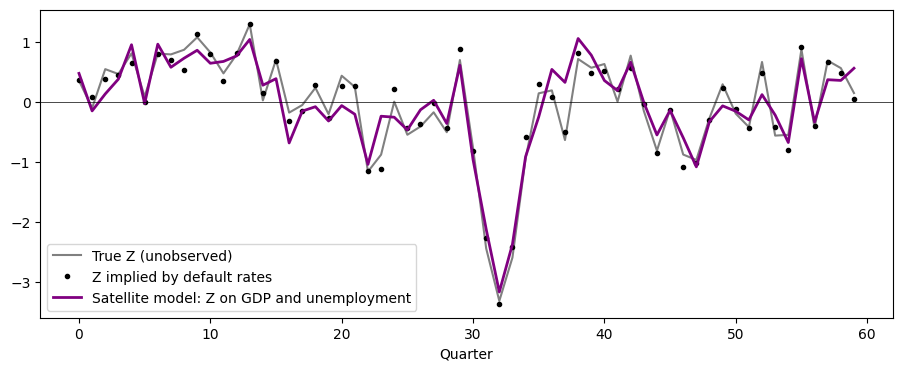

In [16]:
# Step 1: implied Z per grade and quarter, then a weighted average across grades.
z_impl = pd.DataFrame(index=t, columns=grades, dtype=float)
for g in grades:
    rho_g = rho_retail(pd_grade[g])
    dr = dr_hist[g].clip(lower=0.5 / n_grade[g])          # avoid log of zero
    z_impl[g] = (norm.ppf(pd_grade[g]) - norm.ppf(dr) * np.sqrt(1 - rho_g)) / np.sqrt(rho_g)
    
# Weight each grade by the defaults it is expected to produce in a year: a grade with no defaults
# carries no information about Z, and its clipped default rate would only add bias.
w_grade = n_grade * pd_grade
w_grade = w_grade / w_grade.sum()
macro['z_hat'] = (z_impl * w_grade).sum(axis=1)
display(pd.DataFrame({'Loans': n_grade, 'Expected defaults per year': n_grade * pd_grade,
                      'Weight in the implied Z': w_grade}).style.format(
    {'Loans': '{:,.0f}', 'Expected defaults per year': '{:.1f}', 'Weight in the implied Z': '{:.1%}'}))
print(f"Correlation between the recovered Z and the true Z: {macro['z_hat'].corr(macro['z_true']):.3f}")

# Step 2: the satellite model.
X = sm.add_constant(macro[['gdp_growth', 'unemployment']])
sat = sm.OLS(macro['z_hat'], X).fit()
print(sat.summary().tables[1])
beta = sat.params

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, macro['z_true'], color='grey', label='True Z (unobserved)')
ax.plot(t, macro['z_hat'], 'o', ms=3, color='k', label='Z implied by default rates')
ax.plot(t, sat.fittedvalues, color='purple', lw=2, label='Satellite model: Z on GDP and unemployment')
ax.axhline(0, color='k', lw=.5); ax.set_xlabel('Quarter'); ax.legend(); plt.show()

The satellite model recovers most of the systematic factor from two macro series, with the fit falling short in the quarters where the noise term of $Z$ was large. This is the model risk that slide 30 talks about: the unexplained part of $Z$ is a risk in itself. Gross and Población (2019) estimate it at a third of the total uncertainty of a stress test. The residual standard error will be useful for Part 5.

### Three scenarios

The IFRS 9 side needs a base, a downside and an upside, and the Pillar 1 side needs the downside. I define all three on twelve quarters of GDP growth and unemployment, with the base case reverting to trend. The downside is a recession of the size the 1-in-25 value implies: growth three points below trend for four quarters, unemployment up two points, then a slow recovery. The upside is a mild boom. The regression maps each path into $Z$.

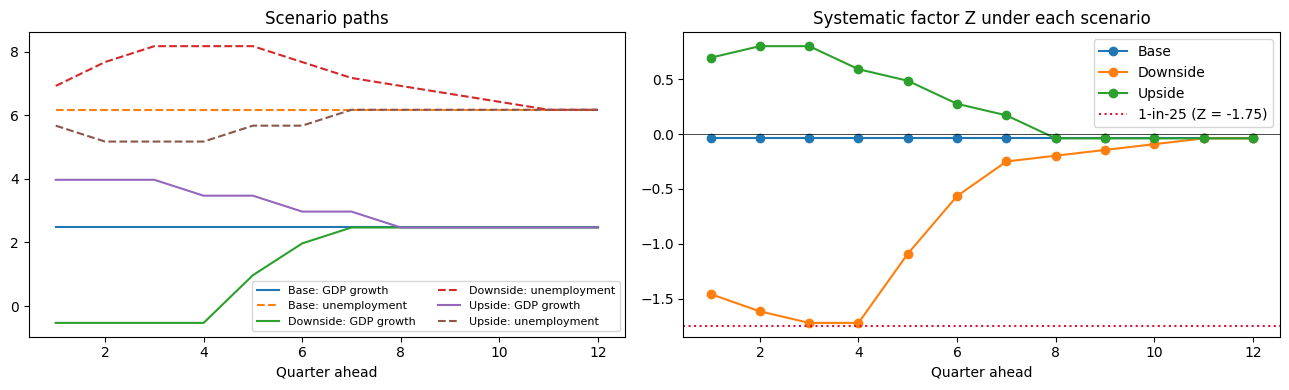

,min Z,mean Z over 12 quarters,weight
Base,-0.0396,-0.0396,0.5000
Downside,-1.7207,-0.7445,0.2500
Upside,-0.0396,0.3018,0.2500


In [17]:
H = 12
q = np.arange(1, H + 1)
gdp_bar, un_bar = gdp.mean(), unemp.mean()
scen_macro = {
    'Base':     pd.DataFrame({'gdp_growth': np.full(H, gdp_bar), 'unemployment': np.full(H, un_bar)}),
    'Downside': pd.DataFrame({'gdp_growth': gdp_bar + np.r_[-3, -3, -3, -3, -1.5, -0.5, 0, 0, 0, 0, 0, 0],
                              'unemployment': un_bar + np.r_[0.75, 1.5, 2, 2, 2, 1.5, 1, 0.75, 0.5, 0.25, 0, 0]}),
    'Upside':   pd.DataFrame({'gdp_growth': gdp_bar + np.r_[1.5, 1.5, 1.5, 1, 1, 0.5, 0.5, 0, 0, 0, 0, 0],
                              'unemployment': un_bar + np.r_[-0.5, -1, -1, -1, -0.5, -0.5, 0, 0, 0, 0, 0, 0]}),
}
weights = {'Base': 0.50, 'Downside': 0.25, 'Upside': 0.25}
z_path = {k: beta['const'] + beta['gdp_growth'] * v['gdp_growth'].values + beta['unemployment'] * v['unemployment'].values
          for k, v in scen_macro.items()}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, v in scen_macro.items():
    ax[0].plot(q, v['gdp_growth'], label=f'{k}: GDP growth'); ax[0].plot(q, v['unemployment'], '--', label=f'{k}: unemployment')
    ax[1].plot(q, z_path[k], marker='o', label=k)
ax[0].set_xlabel('Quarter ahead'); ax[0].set_title('Scenario paths'); ax[0].legend(fontsize=8, ncol=2)
ax[1].axhline(0, color='k', lw=.5); ax[1].axhline(norm.ppf(0.04), color='crimson', ls=':', label='1-in-25 (Z = -1.75)')
ax[1].set_xlabel('Quarter ahead'); ax[1].set_title('Systematic factor Z under each scenario'); ax[1].legend()
plt.tight_layout(); plt.show()
pd.DataFrame({k: {'min Z': v.min(), 'mean Z over 12 quarters': v.mean(), 'weight': weights[k]} for k, v in z_path.items()}).T

The downside path bottoms out near the 1-in-25 line and stays negative for two years. That is the severity slide 19 asks you to check: is the scenario as severe as the supervisory anchors, and is the joint move of growth and unemployment plausible given their history? A path can be made arbitrarily bad by pushing every driver at once, and the lecture's warning is that plausibility is a property of the joint move, not of each driver on its own.

### Pillar 1 result

For the Pillar 1 test I take the downside path, compute the conditional PD of every loan for each of the three years (the annual average of the quarterly $Z$), and roll the losses and the capital ratio forward. Losses are provisioned, so the capital falls by the extra expected loss each year. The risk weights stay on the through-the-cycle PDs, because that is what the IRB formula uses and the formula already holds its own stress at $Z = -3.09$. Putting point-in-time PDs into it would stress twice. I report the point-in-time RWA in a separate column to show how large that double count would be. This is the "gross" test of slide 11: no management actions, credit risk only.

Downside scenario, gross Pillar 1 stress test:


,Z,Portfolio PD,EL (m),Capital (m),Capital ratio (TTC RWA),RWA if PIT PDs were used (m)
Year,,,,,,
1,-1.63,4.30%,11.48,21.8,9.52%,416.4
2,-0.53,2.39%,6.58,21.0,9.17%,245.3
3,-0.08,1.89%,5.28,21.5,9.39%,194.9


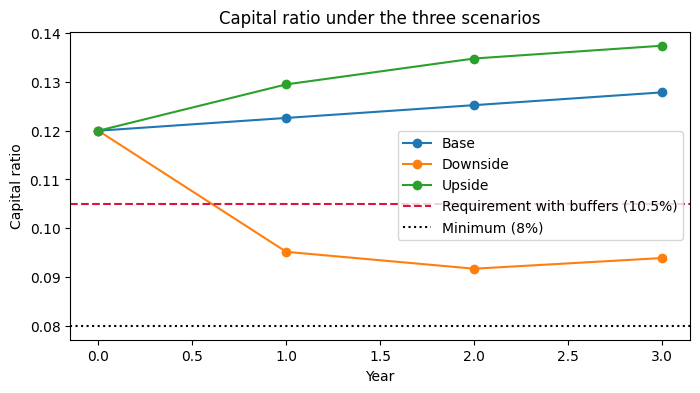

In [20]:
# Quarterly path to three annual averages.
def annual_z(zq):
    return np.array([zq[0:4].mean(), zq[4:8].mean(), zq[8:12].mean()])

# Pillar 1 path under a given Z path, with capital depletion from extra expected loss.
def pillar1_path(zq, df=port):
    za = annual_z(zq)
    rows = []
    capital = CAPITAL0
    for y, z in enumerate(za, start=1):
        p = pd_pit(df['pd_ttc'], df['rho'], z)
        el = (p * df['lgd'] * df['ead']).sum()
        extra = el - df['el'].sum()
        capital = capital - extra
        rwa_pit = (12.5 * k_irb(p, df['lgd'], df['rho']) * df['ead']).sum()     # only to show the double count
        rows.append({'Year': y, 'Z': z, 'Portfolio PD': (p * df['ead']).sum() / df['ead'].sum(), 'EL (m)': el / 1e6,
                     'Capital (m)': capital / 1e6, 'Capital ratio (TTC RWA)': capital / RWA0,
                     'RWA if PIT PDs were used (m)': rwa_pit / 1e6})
    return pd.DataFrame(rows).set_index('Year')

# Run the Pillar 1 stress test under the three scenarios.
p1 = {k: pillar1_path(v) for k, v in z_path.items()}
print('Downside scenario, gross Pillar 1 stress test:')
display(p1['Downside'].style.format({'Z': '{:+.2f}', 'Portfolio PD': '{:.2%}', 'EL (m)': '{:.2f}', 'Capital (m)': '{:.1f}',
                                     'Capital ratio (TTC RWA)': '{:.2%}', 'RWA if PIT PDs were used (m)': '{:.1f}'}))

# Plot the capital ratio under the three scenarios, with the requirement and minimum lines.
fig, ax = plt.subplots(figsize=(8, 4))
for k, v in p1.items():
    ax.plot([0] + list(v.index), [capital_ratio(CAPITAL0, RWA0)] + list(v['Capital ratio (TTC RWA)']), marker='o', label=k)
ax.axhline(REQUIREMENT, color='crimson', ls='--', label='Requirement with buffers (10.5%)')
ax.axhline(MINIMUM, color='k', ls=':', label='Minimum (8%)')
ax.set_xlabel('Year'); ax.set_ylabel('Capital ratio'); ax.legend(); ax.set_title('Capital ratio under the three scenarios')
plt.show()

The downside scenario takes the ratio through the conservation buffer in the first year and leaves it about a point and a half above the 8% minimum (on this portfolio, with these round capital numbers). The ratio only starts to recover once the extra losses stop. That is the design intent of the buffer: a 1-in-25 recession should consume it and not go further into distress. A real result would then list the management actions that bring the ratio back (the "net" test of Pillar 2).

The last column shows what happens if the point-in-time PDs are pushed into the capital formula: the risk-weighted assets rise by more than 80% in the worst year, and the ratio would fall to about 5%, well below the minimum. Under a through-the-cycle philosophy the PDs in the formula do not move, and only migration between grades changes the RWA (the subject of the next part). Under a point-in-time philosophy the formula reprices, and the bank has to hold a buffer for that too. Slide 47 of the validation lecture is the same choice seen from the backtesting side.

## Part 4: Migration under stress

Slide 29 covers Approach 2, which stresses the migration matrix and leaves the PD of each grade unchanged. CRE36.51 asks the bank to "assess migration in its ratings" under the scenario. The Z-shift of Belkin, Suchower and Forest (1998) does it with the same one factor. For each starting grade, the cumulative probabilities of ending in the worst states define thresholds on the normal scale, the thresholds all move by $\sqrt{\rho}\,Z$, rescale by $\sqrt{1-\rho}$, and the stressed matrix follows. One number, $Z$, moves every cell in a consistent direction.

In [21]:
# A through-the-cycle annual migration matrix: the five performing grades, plus D for default.
# The last column is the one-year PD of each grade, so it reproduces pd_grade exactly.
states = grades + ['D']
M_ttc = np.array([
    [0.9200, 0.0700, 0.0090, 0.0005, 0.0000, 0.0005],
    [0.0300, 0.9000, 0.0630, 0.0045, 0.0005, 0.0020],
    [0.0010, 0.0500, 0.8800, 0.0570, 0.0030, 0.0090],
    [0.0000, 0.0050, 0.0700, 0.8400, 0.0500, 0.0350],
    [0.0000, 0.0010, 0.0090, 0.1100, 0.7400, 0.1400],
])
assert np.allclose(M_ttc.sum(axis=1), 1) and np.allclose(M_ttc[:, -1], pd_grade.values)
RHO_MIG = 0.10

# The migration matrix under a given Z, using the one-factor model to shift the PDs of each grade.
def z_shift(M, z, rho=RHO_MIG):
    out = np.zeros_like(M)
    for i in range(M.shape[0]):
        cum = np.cumsum(M[i, ::-1])[:-1]                     # P(D), P(D or C), ..., from the worst state up
        thr = norm.ppf(np.clip(cum, 1e-9, 1 - 1e-9))
        cum_s = norm.cdf((thr - np.sqrt(rho) * z) / np.sqrt(1 - rho))
        out[i] = np.diff(np.r_[0, cum_s, 1])[::-1]
    return out

# Show the through-the-cycle matrix and the stressed matrix under the downside scenario in year 1.
z_down_y1 = annual_z(z_path['Downside'])[0]
M_down = z_shift(M_ttc, z_down_y1)
show = lambda M, title: display(pd.DataFrame(M, index=[f'from {g}' for g in grades], columns=[f'to {s}' for s in states]).style.format('{:.3f}').set_caption(title))
show(M_ttc, 'Through-the-cycle matrix (Z = 0)')
show(M_down, f'Stressed matrix, downside year 1 (Z = {z_down_y1:+.2f})')

,to AAA-AA,to A,to BB,to B,to C,to D
from AAA-AA,0.920,0.070,0.009,0.001,0.000,0.001
from A,0.030,0.900,0.063,0.004,0.001,0.002
from BB,0.001,0.050,0.880,0.057,0.003,0.009
from B,0.000,0.005,0.070,0.840,0.050,0.035
from C,0.000,0.001,0.009,0.110,0.740,0.140


,to AAA-AA,to A,to BB,to B,to C,to D
from AAA-AA,0.826,0.146,0.025,0.002,0.000,0.002
from A,0.006,0.839,0.135,0.012,0.001,0.006
from BB,0.000,0.012,0.835,0.121,0.008,0.026
from B,0.000,0.001,0.019,0.797,0.097,0.086
from C,0.000,0.000,0.001,0.036,0.687,0.276


The default column rises for every grade, the diagonal falls, and the mass moves to the right. To turn this into a capital number, apply the stressed matrix to today's grade distribution, recompute the risk weights with the through-the-cycle PDs of the new grades, and compare with the point-in-time result of Part 3. Under a TTC philosophy this migration effect is the whole of the RWA change.

In [ ]:
dist0 = port.groupby('grade', observed=True)['ead'].sum().reindex(grades).values
dist_ttc = dist0 @ M_ttc
dist_down = dist0 @ M_down
rw = pd.Series({g: 12.5 * k_irb(pd_grade[g], lgd_grade[g], rho_retail(pd_grade[g])) for g in grades})

def rwa_from_dist(dist):
    # Defaulted exposure leaves the performing book, and its loss is provisioned at the
    # portfolio average LGD, which is the proxy used below.
    return (dist[:5] * rw.values).sum(), dist[5]

rwa_ttc, def_ttc = rwa_from_dist(dist_ttc)
rwa_down, def_down = rwa_from_dist(dist_down)
mig = pd.DataFrame({
    'Grade distribution today': np.r_[dist0, 0] / dist0.sum(),
    'After one TTC year': dist_ttc / dist0.sum(),
    'After one downside year': dist_down / dist0.sum(),
}, index=[f'{s} (default)' if s == 'D' else s for s in states])
display(mig.style.format('{:.1%}'))

# Risk weight of the performing book per unit of performing exposure: migration is the whole RWA effect under TTC.
rw_perf_ttc = rwa_ttc / dist_ttc[:5].sum(); rw_perf_down = rwa_down / dist_down[:5].sum()
loss_ttc = def_ttc * port['lgd'].mean(); loss_down = def_down * port['lgd'].mean()
print(f"After one TTC year:      average risk weight of the performing book {rw_perf_ttc:.1%}, defaulted exposure {def_ttc/1e6:5.1f} million, loss on it {loss_ttc/1e6:5.1f} million")
print(f"After one downside year: average risk weight of the performing book {rw_perf_down:.1%}, defaulted exposure {def_down/1e6:5.1f} million, loss on it {loss_down/1e6:5.1f} million")
print(f"Capital ratio after the downside year, migration and default losses only: {(CAPITAL0 - (loss_down - port['el'].sum())) / rwa_down:.2%}")

,Grade distribution today,After one TTC year,After one downside year
AAA-AA,7.4%,7.6%,6.2%
A,24.4%,24.8%,22.1%
BB,42.6%,40.6%,39.4%
B,20.5%,20.3%,22.0%
C,5.1%,4.9%,5.9%
D (default),0.0%,1.9%,4.4%


After one TTC year:      average risk weight of the performing book 38.1%, defaulted exposure  11.2 million, loss on it   4.4 million
After one downside year: average risk weight of the performing book 40.3%, defaulted exposure  26.4 million, loss on it  10.4 million
Capital ratio after the downside year, migration and default losses only: 9.93%


Migration moves the risk weight of the performing book up by a few points, far less than the point-in-time repricing in the last column of Part 3. The TTC PD of each grade does not change; only the loans that cross a grade boundary reprice. The default column captures the remaining risk. The exposure that defaults leaves the performing book and its loss is provisioned. Put together, migration and default losses give a capital ratio close to the Part 3 path: two methods, one scenario, one answer within the model risk margin. A bank has to pick the philosophy that matches how its ratings actually behave.

## Part 5: IFRS 9, the probability-weighted ECL

Slides 32 to 35 move from capital to provisions, where IFRS 9 asks for an expected credit loss that is unbiased and probability-weighted *over a range of outcomes* (paragraph 5.5.17), *forward-looking*, and *computed over twelve months for Stage 1 loans and over the remaining life for Stage 2 and 3*. Our three scenarios and their weights are that range of outcomes.

### Lifetime PD under a scenario path

A scenario gives a $Z$ for each future year. Beyond the twelve quarters of the scenario the path reverts to the long-run mean, $Z \to 0$, linearly over two more years (as a choice). For each loan and each year of its remaining life, the conditional PD follows from the one-factor formula, the survival probability compounds, and the lifetime PD is one minus the survival to maturity (slide 35). The lifetime ECL discounts the marginal loss of each year at a flat 5%.

In [ ]:
# Parameters for the lifetime PD and ECL calculations.
MAX_M = int(port['maturity'].max())
DISCOUNT = 0.05

# Annual Z path for a given quarterly path, with reversion to the mean after year 3.
def z_annual_path(zq, years=MAX_M, revert_years=2):
    za = list(annual_z(zq))
    last = za[-1]
    for k in range(1, years - 3 + 1):
        za.append(last * max(0.0, 1 - k / revert_years))
    return np.array(za[:years])

# Lifetime PD and ECL per loan for a given annual Z path.
def lifetime(df, za, pd_col='pd_ttc'):
    # Returns lifetime PD, 12-month ECL and lifetime ECL per loan for the annual Z path za.
    p = np.column_stack([pd_pit(df[pd_col].values, df['rho'].values, z) for z in za])     # N x years
    alive = (np.arange(1, MAX_M + 1)[None, :] <= df['maturity'].values[:, None])
    p = np.where(alive, p, 0.0)
    surv = np.cumprod(1 - p, axis=1)
    surv_prev = np.column_stack([np.ones(len(df)), surv[:, :-1]])
    marginal = surv_prev * p
    df_t = (1 + DISCOUNT) ** -np.arange(1, MAX_M + 1)
    pd_life = 1 - surv[:, -1]
    ecl_12 = p[:, 0] * df['lgd'].values * df['ead'].values * df_t[0]
    ecl_life = (marginal * df_t[None, :]).sum(axis=1) * df['lgd'].values * df['ead'].values
    return pd_life, ecl_12, ecl_life

# Run the lifetime PD and ECL calculations under the three scenarios.
za_scen = {k: z_annual_path(v) for k, v in z_path.items()}
life = {k: lifetime(port, za) for k, za in za_scen.items()}

# Summarize the results in a table, with the scenario weights.
summary = pd.DataFrame({k: {'Mean lifetime PD': v[0].mean(), '12-month ECL (m)': v[1].sum() / 1e6, 'Lifetime ECL (m)': v[2].sum() / 1e6}
                        for k, v in life.items()}).T
summary['weight'] = pd.Series(weights)
display(summary.style.format({'Mean lifetime PD': '{:.2%}', '12-month ECL (m)': '{:.2f}', 'Lifetime ECL (m)': '{:.2f}', 'weight': '{:.2f}'}))
pd.DataFrame(za_scen, index=[f'Year {y}' for y in range(1, MAX_M + 1)]).T.style.format('{:+.2f}').set_caption('Annual Z paths, with reversion to the mean after year 3')

,Mean lifetime PD,12-month ECL (m),Lifetime ECL (m),weight
Base,6.23%,4.93,15.35,0.50
Downside,8.80%,10.93,21.65,0.25
Upside,5.57%,3.43,13.65,0.25


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7
Base,-0.04,-0.04,-0.04,-0.02,-0.00,-0.00,-0.00
Downside,-1.63,-0.53,-0.08,-0.04,-0.00,-0.00,-0.00
Upside,+0.72,+0.22,-0.04,-0.02,-0.00,-0.00,-0.00


### Weighting the ECLs, and the convexity gap

ECL is convex in $Z$, so the probability-weighted ECL is larger than the ECL of the probability-weighted scenario. A bank that runs one "expected" scenario understates its provision. The EBA found in its 2023 monitoring report that the weighted ECL at most banks sat only 0 to 15% above the base-case ECL, a sign that the non-linearity is often not captured. We can measure the gap on our portfolio in three ways: the weighted sum of the three scenario ECLs, the ECL of the weighted-average path, and a Monte Carlo average over many simulated paths, the quantity that the discrete scenarios approximate.

In [ ]:
# Weighted-average ECL across the three scenarios, and ECL at the weighted-average Z path.
w = pd.Series(weights)
ecl_weighted = sum(w[k] * life[k][2].sum() for k in life)
ecl_12_weighted = sum(w[k] * life[k][1].sum() for k in life)
za_bar = sum(w[k] * za_scen[k] for k in life)
ecl_at_bar = lifetime(port, za_bar)[2].sum()

# Monte Carlo: simulate annual Z paths from the history of the implied Z, an AR(1) with the observed persistence
# and dispersion, starting from today's Z. This is the whole distribution that three scenarios try to summarize.
zq = macro['z_hat'].values
phi_q = np.corrcoef(zq[1:], zq[:-1])[0, 1]
phi = phi_q ** 4                                    # quarterly persistence to annual
sigma_z = zq.std()
sigma_e = sigma_z * np.sqrt(1 - phi ** 2)
z0 = zq[-4:].mean()                                 # Z of the last year
S = 400
ecl_mc = np.zeros(S)
for s in range(S):
    path = np.zeros(MAX_M); z = z0
    for y in range(MAX_M):
        z = phi * z + rng.normal(0, sigma_e); path[y] = z
    ecl_mc[s] = lifetime(port, path)[2].sum()

# Summarize the four ECL estimates in a table, relative to the base scenario.
conv = pd.DataFrame({
    'Lifetime ECL (m)': [life['Base'][2].sum() / 1e6, ecl_at_bar / 1e6, ecl_weighted / 1e6, ecl_mc.mean() / 1e6]},
    index=['Base scenario only', 'One scenario at the weighted-average Z path', 'Probability-weighted over three scenarios', 'Monte Carlo over 400 Z paths'])
conv['Relative to base'] = conv['Lifetime ECL (m)'] / conv.loc['Base scenario only', 'Lifetime ECL (m)'] - 1
display(conv.style.format({'Lifetime ECL (m)': '{:.2f}', 'Relative to base': '{:+.1%}'}))
print(f"Annual persistence of Z: {phi:.2f}; unconditional sd of Z: {sigma_z:.2f}; today's Z: {z0:+.2f}.")
print(f"Monte Carlo ECL: mean {ecl_mc.mean()/1e6:.2f}, 5th to 95th percentile {np.percentile(ecl_mc, 5)/1e6:.2f} to {np.percentile(ecl_mc, 95)/1e6:.2f} million.")

,Lifetime ECL (m),Relative to base
Base scenario only,15.35,+0.0%
One scenario at the weighted-average Z path,15.91,+3.7%
Probability-weighted over three scenarios,16.50,+7.5%
Monte Carlo over 400 Z paths,16.56,+7.9%


Annual persistence of Z: 0.10; unconditional sd of Z: 0.84; today's Z: +0.21.
Monte Carlo ECL: mean 16.56, 5th to 95th percentile 11.63 to 22.72 million.


The weighted ECL lies above the ECL of the averaged path, and the gap between the two rows is the convexity effect on this portfolio. The Monte Carlo row is the benchmark, as it is averaged over the whole distribution of $Z$ paths that history supports. The question for the three-scenario method is how close it gets to that row under our assumptions. The last column can be compared to the EBA's 0 to 15% range: a bank that reports a small gap either has a very mild downside or is averaging scenarios before computing the loss. Remember to **weight the ECLs, never the scenarios**.

## Part 6: IFRS 9's SICR, the threshold matrix and the cliff effect

A loan that moves to Stage 2 causes a significant increase in credit risk since origination. The assessment is relative (B5.5.9): the same increase in PD is more significant for a loan that started at a low PD. The standard gives indicators, a backstop at 30 days past due (5.5.11), and no threshold. The EBA's expectation, from its 2023 monitoring report, is a threefold increase of the annualized lifetime PD as a backstop. I use that trigger, together with a small past-due flag, and compare the lifetime PD under the weighted scenarios today with the lifetime PD the loan had at origination, computed on the same remaining life and at the long-run $Z$.

The cliff effect is what happens to provisions when a downturn pushes many loans over the trigger at once: every loan that crosses swaps a 12-month ECL for a lifetime ECL. The stress test is how a bank sizes that jump, and the threshold matrix of slide 38 is how it documents the trigger by origination band.

In [ ]:
# Lifetime PD at origination: same remaining life, origination PD, long-run Z path (all zeros).
pd_life_orig, _, _ = lifetime(port, np.zeros(MAX_M), pd_col='pd_orig')

# Lifetime PD today under the weighted scenarios, and the two ECL horizons per scenario.
pd_life_now = sum(w[k] * life[k][0] for k in life)
past_due = rng.random(N) < 0.02           # 2% of loans more than 30 days past due, the backstop

# Stage 2 definition: lifetime PD today is at least three times the lifetime PD at origination, or the loan is past due.
def staging(pd_now, pd_orig, multiple=3.0, backstop=past_due):
    return (pd_now >= multiple * pd_orig) | backstop

# Stage 2 provisions: lifetime ECL for Stage 2 loans, 12-month ECL for the rest.
def provisions(stage2, ecl_12, ecl_life):
    return np.where(stage2, ecl_life, ecl_12).sum()

# Stage 2 share and provisions today, using the weighted scenarios.
stage2_now = staging(pd_life_now, pd_life_orig)
ecl_12_w = sum(w[k] * life[k][1] for k in life)
ecl_life_w = sum(w[k] * life[k][2] for k in life)
prov_now = provisions(stage2_now, ecl_12_w, ecl_life_w)
print(f"Stage 2 share today (weighted scenarios): {stage2_now.mean():.1%} of loans, {port.loc[stage2_now, 'ead'].sum()/port['ead'].sum():.1%} of exposure")
print(f"Provisions today: {prov_now/1e6:.2f} million, of which Stage 2 lifetime ECL {ecl_life_w[stage2_now].sum()/1e6:.2f} million")

Stage 2 share today (weighted scenarios): 16.9% of loans, 17.0% of exposure
Provisions today: 7.47 million, of which Stage 2 lifetime ECL 2.27 million


### The threshold matrix

Now we fill the threshold matrix from the portfolio. For each band of origination lifetime PD, the threefold trigger translates into an increase in basis points, and the downside scenario tells us which share of the band crosses it and by how much the band's provision jumps. This is the document a validator asks for: the trigger, its meaning in PD terms, and its consequence under stress.

In [ ]:
# Stage 2 share and provisions in the downside scenario, using the weighted scenarios.
bands = pd.cut(pd_life_orig, [0, 0.02, 0.05, 0.12, 0.30, 1.0], labels=['≤ 2%', '2 to 5%', '5 to 12%', '12 to 30%', '> 30%'])
stage2_down = staging(life['Downside'][0], pd_life_orig)
rows = []

# Summarize the Stage 2 triggers and provisions by origination lifetime PD band.
for b in bands.categories:
    m = np.asarray(bands == b)
    if m.sum() == 0: continue
    p0 = pd_life_orig[m]
    rows.append({
        'Origination lifetime PD band': b,
        'Loans': int(m.sum()),
        'Trigger: lifetime PD increase (bps, median loan)': 1e4 * np.median(2 * p0),        # 3x PD means +2 PD
        'Equivalent multiple': '≥ 3.0×',
        'Stage 2 today': stage2_now[m].mean(),
        'Stage 2 in the downside': stage2_down[m].mean(),
        'Provision jump in the downside (×)': provisions(stage2_down[m], life['Downside'][1][m], life['Downside'][2][m]) /
                                              provisions(stage2_now[m], ecl_12_w[m], ecl_life_w[m]),
    })
matrix = pd.DataFrame(rows).set_index('Origination lifetime PD band')
matrix.style.format({'Trigger: lifetime PD increase (bps, median loan)': '{:,.0f}', 'Stage 2 today': '{:.1%}',
                     'Stage 2 in the downside': '{:.1%}', 'Provision jump in the downside (×)': '{:.2f}'})

,Loans,"Trigger: lifetime PD increase (bps, median loan)",Equivalent multiple,Stage 2 today,Stage 2 in the downside,Provision jump in the downside (×)
Origination lifetime PD band,,,,,,
≤ 2%,10716,80,≥ 3.0×,25.1%,64.3%,2.20
2 to 5%,3238,616,≥ 3.0×,11.1%,11.1%,1.82
5 to 12%,2758,"1,523",≥ 3.0×,8.0%,8.2%,1.67
12 to 30%,2034,"3,562",≥ 3.0×,3.7%,4.6%,1.62
> 30%,1254,"9,440",≥ 3.0×,2.2%,2.2%,1.43


Reading the matrix from left to right, the median loan of the best band started with a lifetime PD of 0.4% and moves to Stage 2 when that PD rises by about 80 basis points, while the median loan of the 5 to 12% band needs about 1,500. The good bands cross the trigger far more often in the downside, because the relative criterion bites hardest on low PDs, and the provision jump concentrates there too. That is the design intent of B5.5.9, and it is also the mechanism of the cliff.

### The cliff effect

To see the cliff as a curve, put the whole economy at one level of $Z$ for the coming years and let it revert as before, then compute the Stage 2 share and the total provision at each level. The provision rises smoothly with the PDs and jumps where the trigger is crossed in bulk.

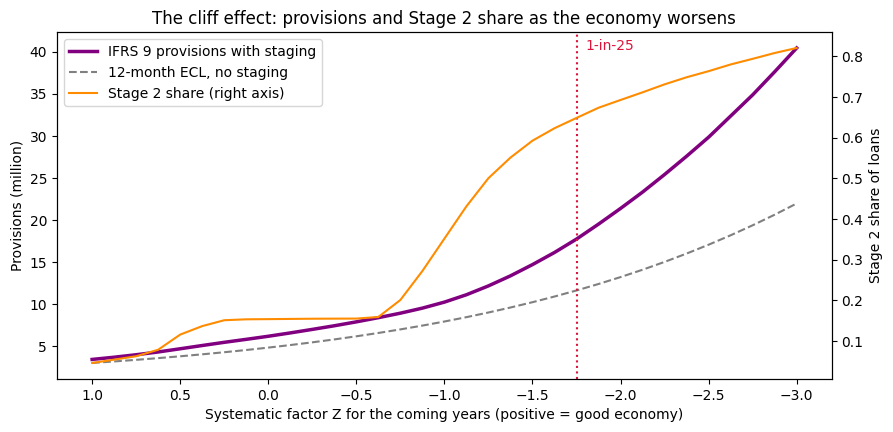

,Z,Stage 2 share,Provisions (m),12-month ECL only (m)
0,+1.00,4.6%,3.43,3.01
4,+0.50,11.6%,4.70,3.81
8,+0.00,15.4%,6.19,4.84
12,-0.50,15.5%,7.90,6.18
16,-1.00,35.2%,10.25,7.94
20,-1.50,59.2%,14.71,10.24
24,-2.00,69.2%,21.38,13.22
28,-2.50,76.3%,29.85,17.07
32,-3.00,82.0%,40.46,21.97


In [ ]:
# Show the cliff effect: provisions and Stage 2 share as the economy worsens, by varying Z.
z_grid = np.linspace(1.0, -3.0, 33)
curve = []

# Compute the Stage 2 share and provisions for each Z in the grid.
for z in z_grid:
    za = np.r_[z, z, z, z * 0.5, 0, 0, 0][:MAX_M]
    pl, e12, elife = lifetime(port, za)
    s2 = staging(pl, pd_life_orig)
    curve.append({'Z': z, 'Stage 2 share': s2.mean(), 'Provisions (m)': provisions(s2, e12, elife) / 1e6,
                  '12-month ECL only (m)': e12.sum() / 1e6})
curve = pd.DataFrame(curve)

# Plot the cliff effect: provisions and Stage 2 share as the economy worsens.
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(curve['Z'], curve['Provisions (m)'], color='purple', lw=2.5, label='IFRS 9 provisions with staging')
ax1.plot(curve['Z'], curve['12-month ECL only (m)'], color='grey', ls='--', label='12-month ECL, no staging')
ax1.set_xlabel('Systematic factor Z for the coming years (positive = good economy)'); ax1.set_ylabel('Provisions (million)')
ax1.invert_xaxis()
ax2 = ax1.twinx(); ax2.plot(curve['Z'], curve['Stage 2 share'], color='darkorange', label='Stage 2 share (right axis)'); ax2.set_ylabel('Stage 2 share of loans')
ax1.axvline(norm.ppf(0.04), color='crimson', ls=':'); ax1.text(norm.ppf(0.04) - 0.05, ax1.get_ylim()[1] * 0.95, '1-in-25', color='crimson')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title('The cliff effect: provisions and Stage 2 share as the economy worsens')
plt.show()
curve.iloc[::4].style.format({'Z': '{:+.2f}', 'Stage 2 share': '{:.1%}', 'Provisions (m)': '{:.2f}', '12-month ECL only (m)': '{:.2f}'})

The dashed line is what provisions would behave without staging: a smooth rise with the PDs. The solid line is IFRS 9, and the distance between the two is the cliff. It opens where the Stage 2 share climbs steeply, and it opens *before* the 1-in-25 line, at a level of stress a bank will see several times in a career. Slide 39 lists what the literature says about the consequences and what banks do about them; this curve is how you measure yours.

## Part 7: Reverse stress testing

Slide 18 turns the question around: which shock exhausts the buffer, and which one doubles the provisions? For one grade the answer is closed-form, since the one-factor formula can be inverted for $Z$ given a target PD. For the portfolio, the search is numerical, and both the capital ratio and the provision are monotone in $Z$. A root-finder on $Z$ is enough to find the shock that exhausts the buffer. I hold the risk weights at their through-the-cycle values and let the IFRS 9 provisions of Part 6 impact capital, so the cliff is inside the search. The satellite model then translates $Z^*$ into a macroeconomic statement, which the committee can discuss and design an action plan on.

In [ ]:
# Closed form for one grade: the Z at which grade B's one-year PD reaches a target.
target = 0.10
g = 'B'
z_star_c = (norm.ppf(pd_grade[g]) - np.sqrt(1 - rho_retail(pd_grade[g])) * norm.ppf(target)) / np.sqrt(rho_retail(pd_grade[g]))
print(f"Grade {g}: PD_TTC {pd_grade[g]:.1%} reaches {target:.0%} at Z* = {z_star_c:+.2f}, a 1-in-{1/norm.cdf(z_star_c):.0f} year.")

# Portfolio: one year at level Z with reversion, provisions via IFRS 9 staging, risk weights through-the-cycle.
def ratio_at(z):
    za = np.r_[z, z * 0.5, 0, 0, 0, 0, 0][:MAX_M]
    pl, e12, elife = lifetime(port, za)
    prov = provisions(staging(pl, pd_life_orig), e12, elife)
    capital = CAPITAL0 - (prov - prov_now)
    return capital / RWA0, prov

z_buffer = brentq(lambda z: ratio_at(z)[0] - REQUIREMENT, -6, 1)
z_minimum = brentq(lambda z: ratio_at(z)[0] - MINIMUM, -6, 1)
z_prov = brentq(lambda z: ratio_at(z)[1] - 2 * prov_now, -6, 1)

def gdp_for_z(z, unemployment=un_bar):
    return (z - beta['const'] - beta['unemployment'] * unemployment) / beta['gdp_growth']

zs = [z_buffer, z_prov, z_minimum]
rev = pd.DataFrame({
    'Z*': zs,
    'Probability of a worse year': [norm.cdf(z) for z in zs],
    'One year in': [1 / norm.cdf(z) for z in zs],
    'GDP growth that produces it (unemployment at its mean)': [gdp_for_z(z) for z in zs],
}, index=['Capital ratio falls to the 10.5% requirement (buffer used up)', 'Provisions double', 'Capital ratio falls to the 8% minimum'])
rev.style.format({'Z*': '{:+.2f}', 'Probability of a worse year': '{:.1%}', 'One year in': '{:,.0f}', 'GDP growth that produces it (unemployment at its mean)': '{:+.1f}%'})

Grade B: PD_TTC 3.5% reaches 10% at Z* = -2.20, a 1-in-72 year.


,Z*,Probability of a worse year,One year in,GDP growth that produces it (unemployment at its mean)
Capital ratio falls to the 10.5% requirement (buffer used up),-1.31,9.6%,10,-0.5%
Provisions double,-1.94,2.6%,38,-2.0%
Capital ratio falls to the 8% minimum,-2.15,1.6%,63,-2.5%


The three answers are the output of the reverse stress test: a severity, expressed as a probability, and a macroeconomic path that produces it. On this portfolio the conservation buffer goes in a year that arrives about once a decade, because the IFRS 9 cliff turns a moderate downturn into a large provision. The minimum holds until a far rarer year. If the $Z^*$ that uses up the buffer is a 1-in-5 year, the buffer is doing what buffers are for, and if the $Z^*$ that breaches the minimum is a 1-in-20 year the bank has a problem. Either way the number is a statement about the bank, and the plausibility of the macro path is the check on the model. The EBA guidelines ask for exactly this use of reverse stress tests, as a challenge to the bank's own scenarios and to the models behind them.


## Summary

- A stress test is a scenario run through the bank's own PD, LGD and EAD models. On this portfolio the same downside scenario produced the Pillar 1 capital path of Part 3, the migration of Part 4 and the provisions of Parts 5 and 6.
- Sensitivity tests are cheap and hard to defend, because they come without a probability. The Basel-formula stress at $Z = -1.75$ is the one that does, and it explains why a flat doubling of PDs is a reasonable 1-in-25 shorthand.
- The systematic factor is the bridge between the macroeconomy and every PD and every migration. The satellite model that builds the bridge is a source of risk in its own right, and the Monte Carlo of Part 5 used its residual.
- ECL is convex in the scenario: weight the ECLs, never the scenarios. Staging adds a cliff on top of the convexity, and the threshold matrix documents where.
- Reverse stress testing turns the result into a severity and a macroeconomic path, the most useful output for a committee.

Everything here runs on a simulated bank. With your own data the steps are the same, but you may not have all the available data needed. Usually the default history is missing: fifteen years with a recession in them is unlikely to be available. A potential solution is to borrow the history from a comparable portfolio or from the supervisor's scenarios, and to say so in the documentation.

### Questions to think about

1. Part 3 provisioned the extra expected loss out of capital every year. IFRS 9 would provision the lifetime ECL of the Stage 2 loans at once. Rerun the Pillar 1 path with the IFRS 9 provisions of Part 6 and compare the capital ratios.
2. Change the mean reversion in `z_annual_path` from two years to five. Which of the three scenarios changes most, and why does the long-maturity part of the book matter here?
3. Replace the threefold trigger with a doubling. How does the cliff curve change, and what does the threshold matrix look like for the best band?
4. The reverse stress test held unemployment at its mean. Hold GDP growth at its mean instead and solve for unemployment. Which of the two statements would a committee find more plausible?

*AI Disclosure: The code and simulations in this lab were generated with the assistance of AI tools.*